Vechile Re-Identificaation using Siamese CNN
This notebbok implemnts a deep learning mode to identify whether two vechile images belong to the same vechile or not

In [1]:
# Importing all the required libraries for deep learning , image processing and evaluation

import torch
import torch.nn as nn
import torch.nn.functional as F

import torchvision.transforms as transforms

from torch.utils.data import Dataset, DataLoader

import numpy as np
import random
import os

from collections import defaultdict

from PIL import Image
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, precision_score, f1_score

from google.colab import files

In [ ]:
# device selection
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [ ]:
# Dataset path setup
dataset_path = "/content/drive/MyDrive/data-sprint-veri.zip"

In [ ]:
# unzipping the dataset into a folder so we can use the images
!unzip -q "/content/drive/MyDrive/data-sprint-veri.zip" -d "/content/veri_dataset"

In [ ]:
# Verifying Dataset Extraction
dataset_path = "/content/veri_dataset"
print(os.listdir(dataset_path))

['VeRi']


In [ ]:
#Exploring Dataset structure
dataset_path = "/content/veri_dataset/VeRi"

print(os.listdir(dataset_path))

['name_query.txt', 'test_track.txt', 'test_label.xml', 'camera_Dist.txt', 'jk_index.txt', 'list_type.txt', 'image_train', 'list_color.txt', 'image_query', 'YongtaiPoint_Google.jpg', 'name_test.txt', 'name_train.txt', 'camera_ID.txt', 'gt_index.txt', 'image_test', 'train_label.xml', 'test_track_VeRi.txt', 'ReadMe.txt']


In [ ]:
# Loading training images
dataset_path = "/content/veri_dataset/VeRi/image_train"

files = os.listdir(dataset_path)

print("Total images:", len(files))
print("Sample files:", files[:5])


Total images: 37778
Sample files: ['0484_c011_00053235_1.jpg', '0317_c011_00014910_0.jpg', '0064_c015_00074710_0.jpg', '0323_c004_00021415_0.jpg', '0343_c003_00034495_0.jpg']


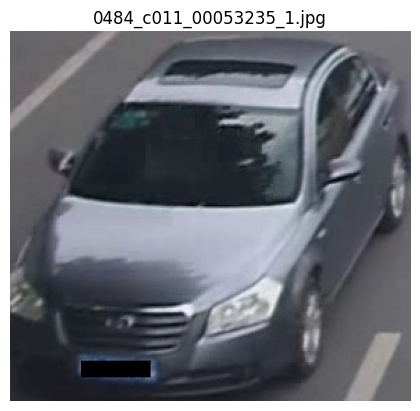

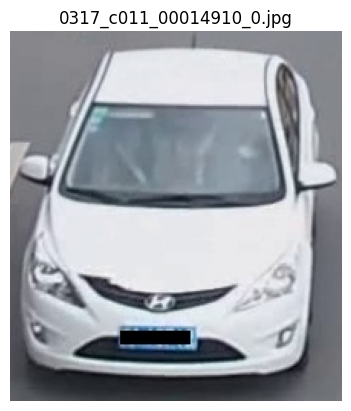

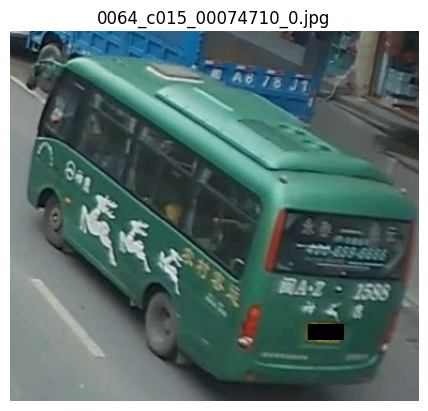

In [ ]:
# Visualizing images from the dataset
for i in range(3):
    img = Image.open(os.path.join(dataset_path, files[i]))
    plt.imshow(img)
    plt.title(files[i])
    plt.axis('off')
    plt.show()

In [ ]:
# Creating pairs of images for similarity learning
# Same vechile - label = 1
# Different vechile - label = 0
label_dict = defaultdict(list)

for file in files:
    vehicle_id = file.split('_')[0]
    label_dict[vehicle_id].append(file)

print("Total vehicles:", len(label_dict))

Total vehicles: 576


In [ ]:
# Creating pair of same vechile
# Because similarity learning requires comparing two samples at a time .
# Using pairs allows the model to learn meaningful relationships
same_pairs = []

for vehicle_id, file_list in label_dict.items():
    if len(file_list) >= 2:
        for i in range(len(file_list)-1):
            same_pairs.append((file_list[i], file_list[i+1], 1))

print("Same pairs:", len(same_pairs))

# Creating pair of different vechiles
vehicle_ids = list(label_dict.keys())
diff_pairs = []

for _ in range(len(same_pairs)):
    v1, v2 = random.sample(vehicle_ids, 2)

    img1 = random.choice(label_dict[v1])
    img2 = random.choice(label_dict[v2])

    diff_pairs.append((img1, img2, 0))

print("Different pairs:", len(diff_pairs))

Same pairs: 37202
Different pairs: 37202


In [ ]:
# Combining and Shuffling pairs
pairs = same_pairs + diff_pairs
random.shuffle(pairs)

# Limiting the dataset size for faster training
pairs = pairs[:3000]

print("Total pairs:", len(pairs))

Total pairs: 3000


In [ ]:
print(pairs[:5])

[('0724_c001_00041275_0.jpg', '0757_c019_00012985_0.jpg', 0), ('0109_c004_00066560_0.jpg', '0109_c007_00067470_0.jpg', 1), ('0155_c002_00015230_0.jpg', '0328_c004_00030715_0.jpg', 0), ('0119_c001_00028760_1.jpg', '0599_c016_00017035_0.jpg', 0), ('0019_c002_00010090_0.jpg', '0019_c006_00008115_0.jpg', 1)]


In [ ]:
# Resizing the image and converting to tensor format
# Preprocessing the data
transform = transforms.Compose([
    transforms.Resize((128, 128)), # rezing the image to 128 X 128
    transforms.ToTensor() # Converting it into numbers because neural networks cannot understand images directly
])

# Custom dataset is created
# So that the model can get data automatically in small groups again and again during training
class PairDataset(Dataset):
    def __init__(self, pairs, dataset_path, transform=None):
        self.pairs = pairs
        self.dataset_path = dataset_path
        self.transform = transform

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img1_name, img2_name, label = self.pairs[idx]

        img1 = Image.open(os.path.join(self.dataset_path, img1_name)).convert("RGB")
        img2 = Image.open(os.path.join(self.dataset_path, img2_name)).convert("RGB")

        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)

        return img1, img2, label

dataset = PairDataset(pairs, dataset_path, transform)

dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

for img1, img2, label in dataloader:
    print(img1.shape)
    print(label[:5])
    break


torch.Size([32, 3, 128, 128])
tensor([1, 0, 1, 0, 1])


In [ ]:
#CNN is implemented to extract feature embeddings from vechile images
#Similar images will have similar embeddings , while different images will have distinct embeddings
class EmbeddingCNN(nn.Module):
    def __init__(self):
        super(EmbeddingCNN, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 16, 3),
            nn.ReLU(), # adds non-linearity , helps learn complex patterns
            nn.MaxPool2d(2),# reduces size ,keeps important features
            #layer 2
            nn.Conv2d(16, 32, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),
            #layer 3
            nn.Conv2d(32, 64, 3),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Linear(64*14*14, 128)
    #defines how data flows
    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

In [ ]:
#Training Setup
# Model Training components are defined
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

model = EmbeddingCNN().to(device)
#Loss Function - This tells the model what is right or wrong
criterion = nn.CosineEmbeddingLoss()
#I have choosen adam because it is fast , smart and adjust learning automatically
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

cpu


In [ ]:
# Training Process
for epoch in range(5):
    total_loss = 0

    for img1, img2, label in dataloader:

        img1 = img1.to(device)
        img2 = img2.to(device)
        label = label.to(device).float()

        label[label == 0] = -1

        f1 = model(img1)
        f2 = model(img2)

        loss = criterion(f1, f2, label)

        optimizer.zero_grad()
        loss.backward()  # back-propogation
        optimizer.step() # updating weights

        total_loss += loss.item()

    print("Epoch:", epoch+1, "Loss:", total_loss)

Epoch: 1 Loss: 47.55044433474541
Epoch: 2 Loss: 38.932049214839935
Epoch: 3 Loss: 41.70362934470177
Epoch: 4 Loss: 48.869719475507736
Epoch: 5 Loss: 48.58859294652939


In [ ]:
# a function is defined to evaluate the similarity between two images
# the similarity score range from -1 to 1
# value closer to 1 indicates that the images are likely of the same vechile
# value close to -1 indicates that the images are different
def check_similarity(img1, img2):
    model.eval()

    with torch.no_grad():
        img1 = img1.unsqueeze(0).to(device)
        img2 = img2.unsqueeze(0).to(device)

        f1 = model(img1)
        f2 = model(img2)

        sim = F.cosine_similarity(f1, f2)

    return sim.item()



In [ ]:
# it selects one random pair of images from my dataset and shows the actual answer
pair = random.choice(pairs)

img1_name, img2_name, label = pair
# 1 - Same Vechile 0 - Different Vechile
print("Actual Label:", label)

Actual Label: 1


In [ ]:
#Testing on Image Pairs
# i am using RGB to ensure 3 colour channels and to avoid errors
img1 = Image.open(os.path.join(dataset_path, img1_name)).convert("RGB")
img2 = Image.open(os.path.join(dataset_path, img2_name)).convert("RGB")
# transform the image
img1 = transform(img1)
img2 = transform(img2)
sim = check_similarity(img1, img2)

print("Similarity Score:", sim)

Similarity Score: 0.8761612772941589


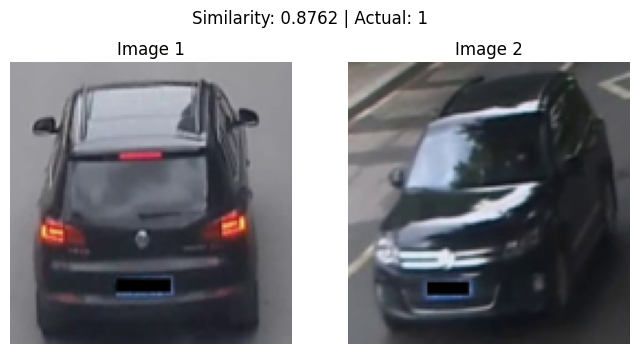

In [ ]:
# Displaying images side by side and similarity score and actual label
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img1.permute(1,2,0))
plt.title("Image 1")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img2.permute(1,2,0))
plt.title("Image 2")
plt.axis('off')

plt.suptitle(f"Similarity: {sim:.4f} | Actual: {label}")

plt.show()

In [ ]:
# Model Evaluation
y_true = []
y_pred = []

total = 200 # testing on random 200 pairs

for _ in range(total):
    pair = random.choice(pairs)
    img1_name, img2_name, label = pair

    img1 = transform(Image.open(os.path.join(dataset_path, img1_name)).convert("RGB"))
    img2 = transform(Image.open(os.path.join(dataset_path, img2_name)).convert("RGB"))

    sim = check_similarity(img1, img2)

    pred = 1 if sim > 0.5 else 0

    y_true.append(label)
    y_pred.append(pred)

# Convert to numpy
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Calculating Accuracy , Precision , F1 score and Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
accuracy = (y_true == y_pred).mean()
precision = precision_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("F1 Score:", f1)
print("Confusion Matrix:\n", cm)

Accuracy: 0.495
Precision: 0.48186528497409326
F1 Score: 0.6480836236933798
Confusion Matrix:
 [[  6 100]
 [  1  93]]


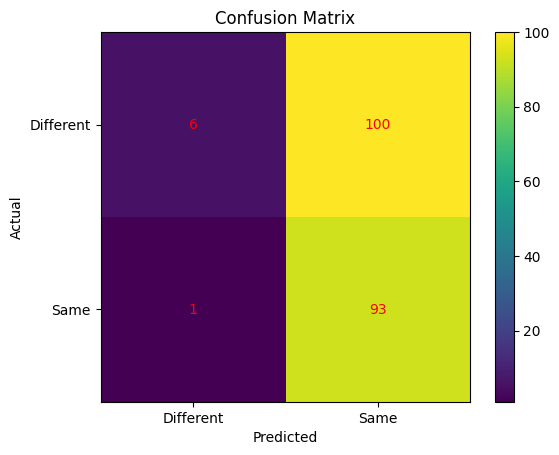

In [ ]:
# Displaying the confusion matrix as a coloured grid
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks([0,1], ["Different", "Same"])
plt.yticks([0,1], ["Different", "Same"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="red")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

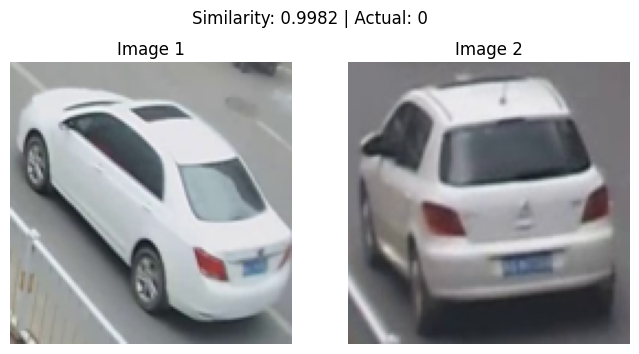

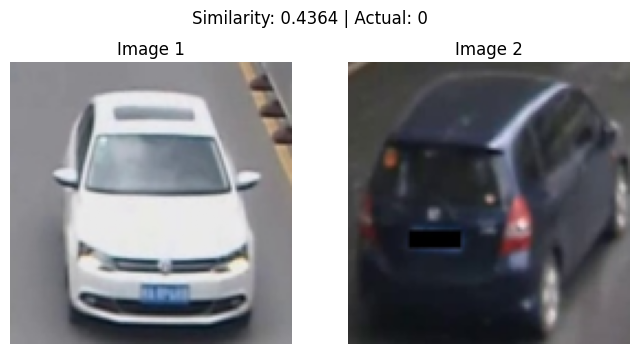

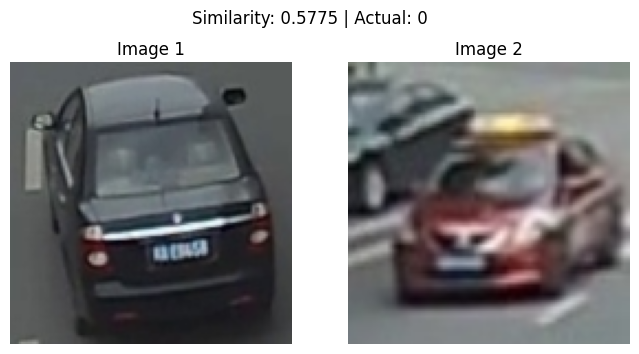

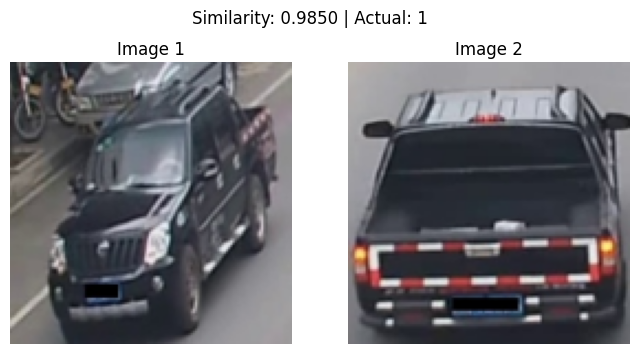

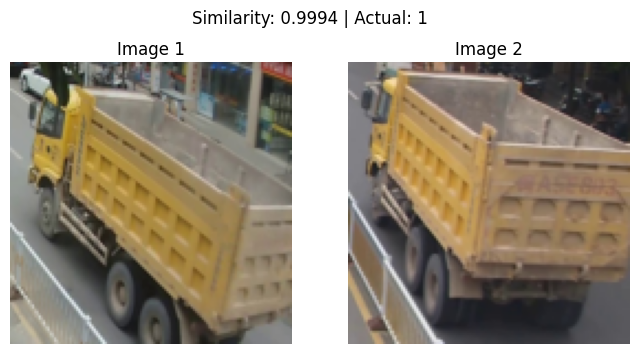

In [ ]:
# Displaying 5 image pairs along with similarity score
for _ in range(5):
    pair = random.choice(pairs)
    img1_name, img2_name, label = pair

    img1 = transform(Image.open(os.path.join(dataset_path, img1_name)).convert("RGB"))
    img2 = transform(Image.open(os.path.join(dataset_path, img2_name)).convert("RGB"))

    sim = check_similarity(img1, img2)

    plt.figure(figsize=(8,4))

    plt.subplot(1,2,1)
    plt.imshow(img1.permute(1,2,0))
    plt.title("Image 1")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(img2.permute(1,2,0))
    plt.title("Image 2")
    plt.axis('off')

    plt.suptitle(f"Similarity: {sim:.4f} | Actual: {label}")

    plt.show()

In [ ]:
# Generating predicition file
import pandas as pd

results = []

total = 200

for _ in range(total):
    pair = random.choice(pairs)
    img1_name, img2_name, label = pair

    img1 = transform(Image.open(os.path.join(dataset_path, img1_name)).convert("RGB"))
    img2 = transform(Image.open(os.path.join(dataset_path, img2_name)).convert("RGB"))

    sim = check_similarity(img1, img2)

    pred = 1 if sim > 0.5 else 0

    results.append([img1_name, img2_name, pred])

df = pd.DataFrame(results, columns=["Image1", "Image2", "Prediction"])

df.to_csv("predictions.csv", index=False)

print("predictions.csv created!")

predictions.csv created!


In [ ]:
# Downloading the Predicted output file
from google.colab import files
files.download("predictions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Saving the training model
torch.save(model.state_dict(), "model.pth")

In [ ]:
# Downloading trained machine learning model
from google.colab import files
files.download("model.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>